# ML from DFT data

- [ ] learn on separated FM and NM AGAIN
- [ ] remove high order BOP features before learing
- [ ] Recursive Feature elimination after removing high order features
- [ ] make recursion on bond energy
- [ ] change OS to 1/10,
- [ ] 1/10 OS and scf bop
- learn form library features
- compare different regression methods
   - Linear regression
   - add SVM
   - kernel methods
   - Gaussian process.
- compare different test-train splittings
- Learn on increasing domain knowledge

 - input: clean features dataframes from pickles
 - output : plots and Models

In [1]:
from Tools.DatasetTools.Commoms import *

In [2]:
plt.rc('figure', figsize=(18, 8))
plt.rc('font', size=22)
from matplotlib.lines import Line2D

# Parameters 

In [3]:
from Tools.DatasetTools.DatasetOperator import Dataset

['/home/storage/fortimtb/DatasetsML', '/home/storage/fortimtb/DatasetsML', '/scratch/AnacondaEnvironments/ml_datasets/lib/python39.zip', '/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9', '/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/lib-dynload', '', '/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/site-packages', '/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/site-packages/ipython_genutils-0.2.0-py3.9.egg', '/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/site-packages/webencodings-0.5.1-py3.9.egg', '/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/site-packages/maxvolpy-0.3.8-py3.9-linux-x86_64.egg']


In [4]:
target_name = 'EF_nmhcp'

In [5]:
DS = Dataset('Fe-Mo', target_name=target_name)

In [6]:
DS.BS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_nmhcp,EF_nmfcc,EF_fmbcc,Phase
Fe_pv8.A15.FM,bulk A15.FM,11.558019 A,-8.169759,91.497861 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,8,0,8,1.000000,0.000000,0.085535,0.085535,0.085535,A15
Fe_pv12.C14.FM,bulk C14.FM,12.119019 A,-8.105991,102.152576 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,12,0,12,1.000000,0.000000,0.149303,0.149303,0.149303,C14
Fe_pv24Mo_sv5.chi-BBAA.FM,bulk chi-BBAA.FM,11.926180 A,-8.658669,124.301732 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,24,5,29,0.827586,0.172414,0.058514,0.058514,0.058514,chi
Fe_pv25Mo_sv4.chi-ABAA.FM,bulk chi-ABAA.FM,11.874474 A,-8.560894,134.837320 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,25,4,29,0.862069,0.137931,0.063911,0.063911,0.063911,chi
Fe_pv24.C36.FM,bulk C36.FM,12.049606 A,-8.109714,150.452690 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,24,0,24,1.000000,0.000000,0.145580,0.145580,0.145580,C36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv25Mo_sv4.chi-ABAA.NM,bulk chi-ABAA,11.072302 A,-8.505552,279.868523 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,25,4,29,0.862069,0.137931,0.057857,-0.010307,0.119258,chi
Fe_pv16Mo_sv8.C36-BBAAA.NM,bulk C36-BBAAA,12.044661 A,-9.117739,281.820517 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,16,8,24,0.666667,0.333333,-0.016932,-0.069645,0.030551,C36
Fe_pv8Mo_sv4.C14-BAA.NM,bulk C14-BAA,12.031891 A,-9.133101,282.397960 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,8,4,12,0.666667,0.333333,-0.032294,-0.085007,0.015189,C14
Fe_pv4.fcc-cubic.NM,bulk fcc-cubic,10.248696 A,-8.104999,283.740438 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,4,0,4,1.000000,0.000000,0.079070,0.000000,0.150295,fcc


# Targets

Text(0.5, 0, '$V_0$')

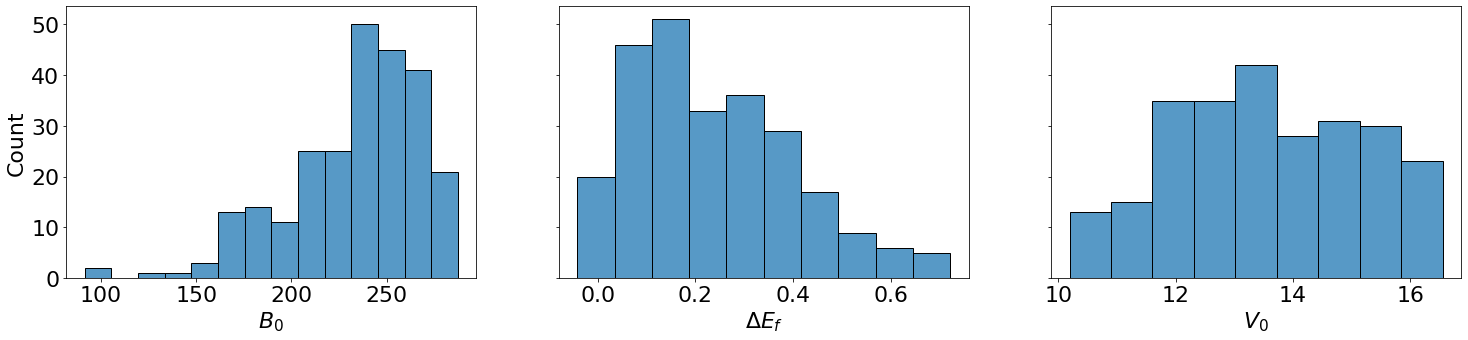

In [7]:
fig, ax = plt.subplots(1,3, figsize=(25, 5), sharey = True)
sns.histplot( DS.BS['B0'], ax= ax[0])
sns.histplot( DS.BS[target_name], ax= ax[1])
sns.histplot( DS.BS['V0'], ax= ax[2])
ax[0].set_xlabel(r'$B_0$')
ax[1].set_xlabel(r'$\Delta E_f$')
ax[2].set_xlabel(r'$V_0$')

# Machine Learning 

In [8]:
from Tools.DatasetTools.MLConveniences import *

In [9]:
resultslocation = DS.resultslocation

## Feature sets

In [10]:
Features = DS.Features  # {name: pd.read_pickle(filename) for name, filename in DescriptorFileList.items()}

In [11]:
Features['Canonical BOP']

,Structure,Mag,U_bind,U_bond_atom_list_1_0,U_bond_atom_list_1_CN12,U_bond_atom_list_1_CN13,U_bond_atom_list_1_CN14,U_bond_atom_list_1_CN15,U_bond_atom_list_1_CN16,moments_1_0,...,Binf_1_CN14,Binf_1_CN15,Binf_1_CN16,sf_0,sf_CN12,sf_CN13,sf_CN14,sf_CN15,sf_CN16,random
Fe_pv8.A15.FM,0,1,-24.768177,-5.818838,-0.766079,0.000000,-5.052759,0.0,0.000000,1.563775,...,1.061958,0.0,0.000000,1.195485,1.256253,0.000000,1.177464,0.0,0.000000,0.587810
Fe_pv12.C14.FM,1,1,-30.393489,-6.385967,-2.746742,0.000000,0.000000,0.0,-3.639226,1.735289,...,0.000000,0.0,0.563851,1.106264,1.192872,0.000000,0.000000,0.0,0.904117,0.507328
Fe_pv24Mo_sv5.chi-BBAA.FM,6,1,-48.743360,-6.846426,-1.822605,-1.296988,0.000000,0.0,-3.726834,1.462959,...,0.000000,0.0,0.208855,1.251704,1.437264,1.179086,0.000000,0.0,1.006209,0.499968
Fe_pv25Mo_sv4.chi-ABAA.FM,6,1,-55.370290,-6.786187,-1.810551,-1.271219,0.000000,0.0,-3.704418,1.481429,...,0.000000,0.0,0.210169,1.251702,1.437269,1.179082,0.000000,0.0,1.006200,0.606674
Fe_pv24.C36.FM,3,1,-61.028417,-6.696704,-6.199370,0.000000,0.000000,0.0,-0.497334,1.750070,...,0.000000,0.0,0.581228,1.081733,1.156286,0.000000,0.000000,0.0,0.901324,0.806611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv25Mo_sv4.chi-ABAA.NM,6,0,-55.370290,-6.786187,-1.810551,-1.271219,0.000000,0.0,-3.704418,1.481429,...,0.000000,0.0,0.210169,1.251702,1.437269,1.179082,0.000000,0.0,1.006200,0.635410
Fe_pv16Mo_sv8.C36-BBAAA.NM,3,0,0.653078,-7.534095,-3.218117,0.000000,0.000000,0.0,-4.315978,1.550432,...,0.000000,0.0,0.547073,1.081733,1.156284,0.000000,0.000000,0.0,0.901328,0.306291
Fe_pv8Mo_sv4.C14-BAA.NM,1,0,-0.173778,-7.354415,-3.092435,0.000000,0.000000,0.0,-4.261981,1.537340,...,0.000000,0.0,0.530717,1.106266,1.192873,0.000000,0.000000,0.0,0.904120,0.987062
Fe_pv4.fcc-cubic.NM,7,0,-12.039661,-5.267352,-5.267352,0.000000,0.000000,0.0,0.000000,1.388730,...,0.000000,0.0,0.000000,1.140021,1.140021,0.000000,0.000000,0.0,0.000000,0.283675


In [12]:
Features.keys()

dict_keys(['atomic', 'dataset', 'SOAP_canonicalFe', 'SOAP_canonicalW', 'SOAP_specific', 'Pyscal', 'ACE', 'Canonical BOP', 'Projections BOP', 'Projections OS BOP', '0.6 Projections OS BOP', '0.7 Projections OS BOP', '0.8 Projections OS BOP', 'dataset + Canonical BOP', 'dataset + Projections BOP', 'dataset + Projections OS BOP', 'dataset + 0.6 Projections OS BOP', 'dataset + 0.7 Projections OS BOP', 'dataset + 0.8 Projections OS BOP', 'atomic no CNAV', 'dataset no CNAV', 'SOAP_canonicalFe no CNAV', 'SOAP_canonicalW no CNAV', 'SOAP_specific no CNAV', 'Pyscal no CNAV', 'ACE no CNAV', 'Canonical BOP no CNAV', 'Projections BOP no CNAV', 'Projections OS BOP no CNAV', '0.6 Projections OS BOP no CNAV', '0.7 Projections OS BOP no CNAV', '0.8 Projections OS BOP no CNAV', 'dataset + Canonical BOP no CNAV', 'dataset + Projections BOP no CNAV', 'dataset + Projections OS BOP no CNAV', 'dataset + 0.6 Projections OS BOP no CNAV', 'dataset + 0.7 Projections OS BOP no CNAV', 'dataset + 0.8 Projections OS

## test - train splits

In [13]:
samplesplit = DS.get_samplesplit()

# Optimized Models

In [14]:
models = ['Kernel Ridge', 'Random Forest','MLP']

In [15]:
scoresfiles = {model:f'{DS.dataset}/results/{DS.dataset}_{model}_OptimalScores_{target_name}.pkl'
              for model in models}

In [16]:
scoresfiles

{'Kernel Ridge': 'Fe-Mo/results/Fe-Mo_Kernel Ridge_OptimalScores_EF_nmhcp.pkl',
 'Random Forest': 'Fe-Mo/results/Fe-Mo_Random Forest_OptimalScores_EF_nmhcp.pkl',
 'MLP': 'Fe-Mo/results/Fe-Mo_MLP_OptimalScores_EF_nmhcp.pkl'}

In [17]:
OptimizedScores = {
    model: pd.read_pickle(scoresfiles[model])
    for model in models if os.path.exists(scoresfiles[model]) 
}

In [18]:
OptimizedScoresDF = pd.concat(OptimizedScores.values(), axis=0)

In [19]:
OptimizedScoresDF

test     train
Kernel Ridge  0.6 Projections OS BOP          0.032330  0.025913
              0.7 Projections OS BOP          0.029837  0.008938
              0.7 Projections OS BOP no CNAV  0.050276  0.032414
              0.8 Projections OS BOP          0.045273  0.025014
              ACE                             0.020448  0.030571
              ACE no CNAV                     0.035146  0.013976
              Canonical BOP                   0.071510  0.067207
              Canonical BOP no CNAV           0.077252  0.070964
              Projections OS BOP              0.037796  0.008869
              SOAP_specific                   0.028275  0.020549
              SOAP_specific no CNAV           0.039712  0.040209
              atomic                          0.142624  0.153541
              atomic no CNAV                  0.278512  0.284192
              dataset                         0.074479  0.070611
              dataset no CNAV                 0.280363  0.284930
Random Forest 0.6 Projections OS BOP          0.046685  0.026667
              0.7 Projections OS BOP          0.051006  0.026594
              0.7 Projections OS BOP no CNAV  0.062751  0.028748
              0.8 Projections OS BOP          0.050855  0.030065
              ACE no CNAV                     0.042708  0.026894
              Canonical BOP                   0.076102  0.041978
              Canonical BOP no CNAV           0.092791  0.038076
              Projections OS BOP              0.048063  0.028069
              SOAP_canonicalFe                0.110009  0.100436
              SOAP_specific                   0.051847  0.022609
              SOAP_specific no CNAV           0.059568  0.031594
              atomic                          0.118279  0.106610
              dataset                         0.085789  0.041841
MLP           0.6 Projections OS BOP          0.051036  0.051469
              0.7 Projections OS BOP          0.050742  0.046347
              0.7 Projections OS BOP no CNAV  0.056873  0.046121
              0.8 Projections OS BOP          0.063871  0.066962
              ACE no CNAV                     0.039968  0.049292
              Canonical BOP                   0.060514  0.049794
              Canonical BOP no CNAV           0.068085  0.055115
              Projections OS BOP              0.047238  0.045415
              SOAP_canonicalFe                0.129776  0.140718
              SOAP_specific                   0.036898  0.035474
              SOAP_specific no CNAV           0.055078  0.055258
              atomic                          0.140231  0.152921
              dataset                         0.091982  0.083755

In [20]:
unstack = OptimizedScoresDF.unstack(level=0)

In [21]:
unstack

test                          \
                               Kernel Ridge       MLP Random Forest   
0.6 Projections OS BOP             0.032330  0.051036      0.046685   
0.7 Projections OS BOP             0.029837  0.050742      0.051006   
0.7 Projections OS BOP no CNAV     0.050276  0.056873      0.062751   
0.8 Projections OS BOP             0.045273  0.063871      0.050855   
ACE                                0.020448       NaN           NaN   
ACE no CNAV                        0.035146  0.039968      0.042708   
Canonical BOP                      0.071510  0.060514      0.076102   
Canonical BOP no CNAV              0.077252  0.068085      0.092791   
Projections OS BOP                 0.037796  0.047238      0.048063   
SOAP_canonicalFe                        NaN  0.129776      0.110009   
SOAP_specific                      0.028275  0.036898      0.051847   
SOAP_specific no CNAV              0.039712  0.055078      0.059568   
atomic                             0.142624  0.140231      0.118279   
atomic no CNAV                     0.278512       NaN           NaN   
dataset                            0.074479  0.091982      0.085789   
dataset no CNAV                    0.280363       NaN           NaN   

                                      train                          
                               Kernel Ridge       MLP Random Forest  
0.6 Projections OS BOP             0.025913  0.051469      0.026667  
0.7 Projections OS BOP             0.008938  0.046347      0.026594  
0.7 Projections OS BOP no CNAV     0.032414  0.046121      0.028748  
0.8 Projections OS BOP             0.025014  0.066962      0.030065  
ACE                                0.030571       NaN           NaN  
ACE no CNAV                        0.013976  0.049292      0.026894  
Canonical BOP                      0.067207  0.049794      0.041978  
Canonical BOP no CNAV              0.070964  0.055115      0.038076  
Projections OS BOP                 0.008869  0.045415      0.028069  
SOAP_canonicalFe                        NaN  0.140718      0.100436  
SOAP_specific                      0.020549  0.035474      0.022609  
SOAP_specific no CNAV              0.040209  0.055258      0.031594  
atomic                             0.153541  0.152921      0.106610  
atomic no CNAV                     0.284192       NaN           NaN  
dataset                            0.070611  0.083755      0.041841  
dataset no CNAV                    0.284930       NaN           NaN

In [22]:
iwanttoplot = unstack.index.difference(['SOAP', 'dataset + Projections BOP', 'Projections BOP', 'dataset + Projections sOS BOP', 'Projections OS BOP'])

In [23]:
test_scores = unstack['test'].loc[iwanttoplot].sort_values(by='Kernel Ridge', ascending=False)#.dropna(axis=0)

In [24]:
test_scores

,Kernel Ridge,MLP,Random Forest
dataset no CNAV,0.280363,NaN,NaN
atomic no CNAV,0.278512,NaN,NaN
atomic,0.142624,0.140231,0.118279
Canonical BOP no CNAV,0.077252,0.068085,0.092791
dataset,0.074479,0.091982,0.085789
Canonical BOP,0.071510,0.060514,0.076102
0.7 Projections OS BOP no CNAV,0.050276,0.056873,0.062751
0.8 Projections OS BOP,0.045273,0.063871,0.050855
SOAP_specific no CNAV,0.039712,0.055078,0.059568
ACE no CNAV,0.035146,0.039968,0.042708


In [25]:
no_cnav = {}
cnav = {}
regrouped= {}
for model in test_scores.columns:
    no_cnav[model] = test_scores.query('index.str.contains("no CNAV")')[[model]]
    cnav[model] = test_scores.query('~index.str.contains("no CNAV")')[[model]]
    no_cnav[model].index  = no_cnav[model].index.str.replace(' no CNAV','')
    regrouped[model] = pd.concat([cnav[model] , no_cnav[model]], axis = 1)#.dropna()
    regrouped[model].columns = ['CNAV', 'no CNAV']

In [26]:
regrouped['Random Forest']

,CNAV,no CNAV
atomic,0.118279,NaN
dataset,0.085789,NaN
Canonical BOP,0.076102,0.092791
0.8 Projections OS BOP,0.050855,NaN
0.6 Projections OS BOP,0.046685,NaN
0.7 Projections OS BOP,0.051006,0.062751
SOAP_specific,0.051847,0.059568
ACE,NaN,0.042708
SOAP_canonicalFe,0.110009,NaN


In [27]:
regrouped['Kernel Ridge']

,CNAV,no CNAV
atomic,0.142624,0.278512
dataset,0.074479,0.280363
Canonical BOP,0.071510,0.077252
0.8 Projections OS BOP,0.045273,NaN
0.6 Projections OS BOP,0.032330,NaN
0.7 Projections OS BOP,0.029837,0.050276
SOAP_specific,0.028275,0.039712
ACE,0.020448,0.035146
SOAP_canonicalFe,NaN,NaN


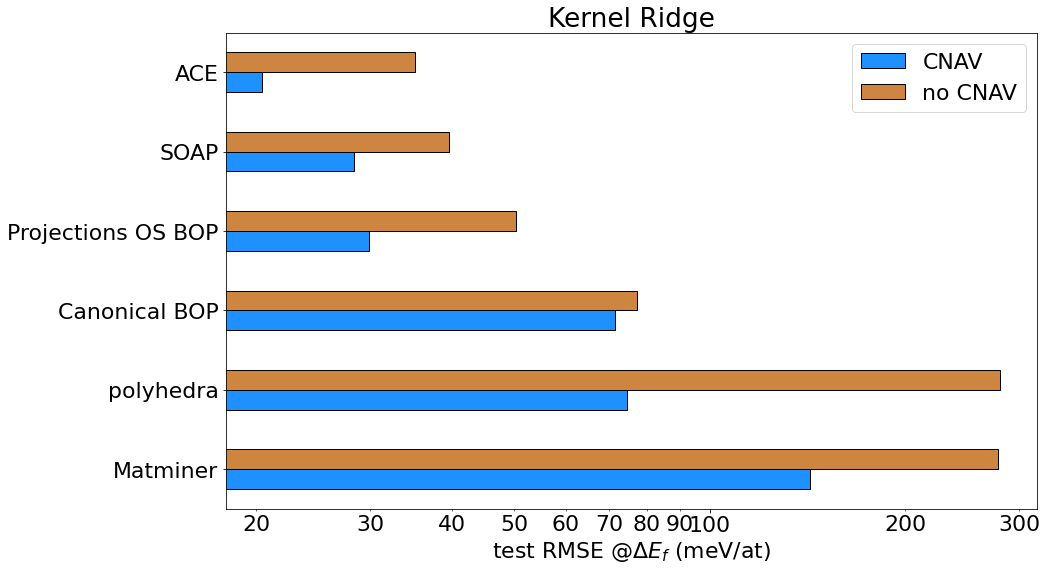

In [40]:
ModelName = 'Kernel Ridge'
h = regrouped[ModelName].dropna().shape[0]
fig, ax =  plt.subplots(figsize=(15, 1.2*(h+1)))
ax = (1000*regrouped[ModelName].dropna()).plot.barh(color = ['dodgerblue', 'peru'], edgecolor='k', ax = ax, width=0.5)
ax.set_xscale('log')
xlabels = ax.get_yticklabels()
newlabels = [l.get_text().replace('+','+\n') for l in xlabels]
newlabels = [l.replace('_specific','') for l in newlabels]
newlabels = [l.replace('Pyscal','Steinhardt') for l in newlabels]
newlabels = [l.replace('atomic','Matminer') for l in newlabels]
newlabels = [l.replace('dataset','polyhedra') for l in newlabels]
newlabels = [l.replace('sOS','OS') for l in newlabels]
newlabels = [l.replace('0.7 ', '') for l in newlabels]
xls = ax.set_yticklabels(newlabels)
ax.tick_params(axis='x', which='minor')
ax.xaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
ax.tick_params(axis='x', which='major')
ax.xaxis.set_major_formatter(FormatStrFormatter("%.0f"))
ax.set_xlabel(r'test RMSE @$\Delta E_f$ (meV/at)')
ax.set_title(ModelName)
plt.tight_layout()
plt.savefig(os.path.join(DS.dataset,'graphs', f'{DS.dataset}_structural_domain_{ModelName}_{target_name}.pdf'))

In [29]:
models = pd.DataFrame.from_dict({modelname: regrouped_scores['CNAV'] for modelname, regrouped_scores in regrouped.items()})

In [30]:
models.index = models.index.str.replace('_specific','')

In [31]:
models = models.query('~index.str.contains("^0.8|^0.6|canonicalFe")')

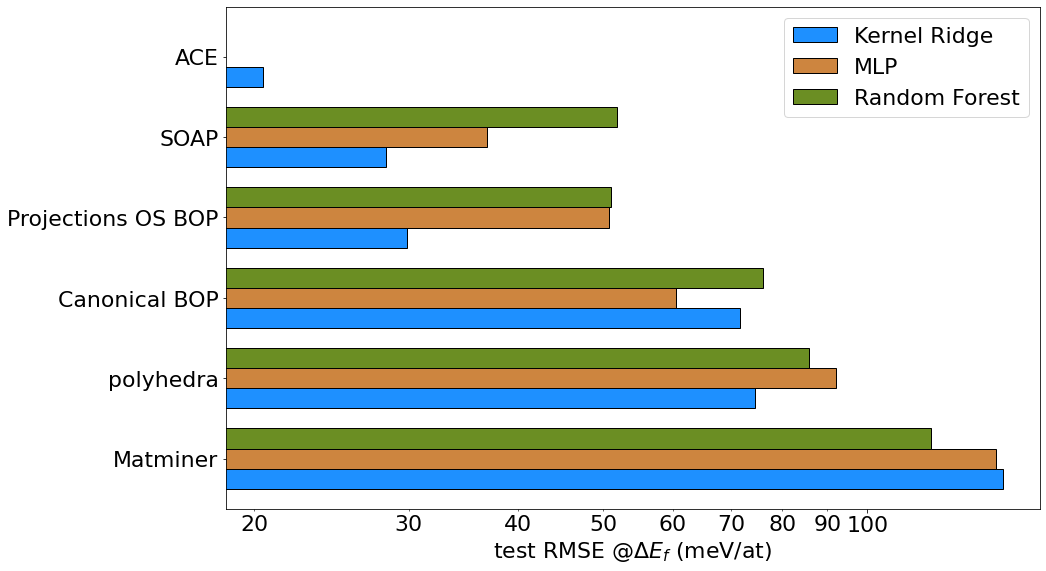

In [41]:
h = models.shape[0]
fig, ax = plt.subplots(figsize=(15, 1.2*(h+1)))
ax = (1000*models).sort_values(by='Kernel Ridge', ascending = False).plot.barh(
    color = ['dodgerblue', 'peru', 'olivedrab'],
    edgecolor='k',
    ax = ax, 
    width = 0.75
)
ax.set_xscale('log')
xlabels = ax.get_yticklabels()
newlabels = [l.get_text().replace('+','+\n') for l in xlabels]
newlabels = [l.replace('Pyscal','Steinhardt') for l in newlabels]
newlabels = [l.replace('atomic','Matminer') for l in newlabels]
newlabels = [l.replace('dataset','polyhedra') for l in newlabels]
newlabels = [l.replace('sOS','OS') for l in newlabels]
newlabels = [l.replace('0.7 ', '') for l in newlabels]
xls = ax.set_yticklabels(newlabels)
ax.tick_params(axis='x', which='minor')
ax.xaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
ax.tick_params(axis='x', which='major')
ax.xaxis.set_major_formatter(FormatStrFormatter("%.0f"))
ax.set_xlabel(r'test RMSE @$\Delta E_f$ (meV/at)')
fig.tight_layout()
fig.savefig(os.path.join(DS.dataset,'graphs', f'{DS.dataset}_comparemodels_{ModelName}_{target_name}.pdf'))

# Random Forest regressor 

In [33]:
groups = {'moments':'^moments$|Mag','normed_moments':'^normed|Mag', 'recursion coeficients':'an_.*|bn_.*|Mag', 
         'sigmas':'sigma.*|Mag'}

In [34]:
simplebopresultslocation = os.path.join(resultslocation, 'simpleresults_rs_41.pkl')

In [35]:
RMSE = {}
if os.path.exists(simplebopresultslocation):
    dfRMSE = pd.read_pickle(simplebopresultslocation)
## BOP, full dataset
    RMSE = dfRMSE.to_dict(orient='index')

In [36]:
progress = tqdm(product(groups.items(), Features_train.items()), total=len(groups)*len(Features))
for (group, regex), (trainfeaturesname, trainfeatures) in progress:
    testfeaturesname = trainfeaturesname
    testfeatures = Features_test[testfeaturesname]
    if 'BOP' not in trainfeaturesname:
        continue
    if ('full', trainfeaturesname, group) not in RMSE.keys():
        xtrain = trainfeatures.filter(regex=regex)  # .dropna()
        xtest = testfeatures[xtrain.columns]  # .filter(regex=regex).dropna()
        ytrain = BS['EF'][xtrain.index]
        ytest = BS['EF'][xtest.index]
        model = RandomForestRegressor(random_state=42, max_depth=20)
        model.fit(xtrain, ytrain)
        RMSE[('full', trainfeaturesname, group)] = score_fitted_model(model, xtrain, xtest, ytrain, ytest)

## BOP on FM samples

    if ('FM', trainfeaturesname, group) not in RMSE.keys():
        fmselection = Features_train['dataset']['Mag']==0
        xtrain = trainfeatures.filter(regex=regex)[fmselection]  # .dropna()
        xtest = testfeatures[xtrain.columns]  # .filter(regex=regex).dropna()
        ytrain = BS['EF'][xtrain.index]
        ytest = BS['EF'][xtest.index]
        model = RandomForestRegressor(random_state=42, max_depth=20)
        model.fit(xtrain, ytrain)
        RMSE[('FM', trainfeaturesname, group)] = score_fitted_model(model, xtrain, xtest, ytrain, ytest)

## BOP on nonmagnetic samples

    if ('NM', trainfeaturesname , group) not in RMSE.keys():
        nmselection = Features_train['dataset']['Mag']==1
        xtrain = trainfeatures.filter(regex=regex)[nmselection]#.dropna()
        xtest = testfeatures[xtrain.columns]#.filter(regex=regex).dropna()
        ytrain = BS['EF'][xtrain.index]
        ytest = BS['EF'][xtest.index]
        model = RandomForestRegressor(random_state=42, max_depth = 20)
        model.fit(xtrain, ytrain)
        RMSE[('NM', trainfeaturesname, group)] = score_fitted_model(model, xtrain, xtest, ytrain, ytest)

dfRMSE = pd.DataFrame.from_dict(RMSE, orient='index').sort_values(by='test')
dfRMSE.to_pickle(simplebopresultslocation)

NameError: name 'Features_train' is not defined

In [ ]:
fractions  = dfRMSE.index.get_level_values(0).unique()

Partial selections for the plots

In [ ]:
fulls = dfRMSE.index.get_level_values(0).str.contains('full')#.str.contains('^(?!.*CNAV)')
fms = dfRMSE.index.get_level_values(0).str.contains('FM')#.str.contains('^(?!.*CNAV)')
nms = dfRMSE.index.get_level_values(0).str.contains('NM')#.str.contains('^(?!.*CNAV)')
nocnav = dfRMSE.index.get_level_values(1).str.contains('^(?!.*CNAV.*)')
withzeros = dfRMSE.index.get_level_values(1).str.contains('^(?!.*no Zeros.*)')

In [ ]:
plt.rc('figure', figsize=(12,8))
plt.rc('font', size=22)

In [ ]:
colors = {'Canonical BOP': 'Blues',  'Projections BOP': 'greens', 'Projections OS BOP': ['green', 'ocean']}
fix, axes = plt.subplots(len(fractions), 1, figsize = (10, 15), sharex=True)
for ax, (ds, groups ) in zip(axes, dfRMSE.loc[(fulls | fms | nms) & nocnav & withzeros].groupby(level=0)):
    ax.set_title(ds)
    for group, scores  in groups.groupby(level=1):
        ax.barh(scores.index.get_level_values(2), scores['test'], label=group)
ax.legend(bbox_to_anchor = (1.1, 0.9))
ax.set_xlim(0.025, 0.06)
ax.set_xlabel('RMSE $\Delta E_f$ @test')
#ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


In [ ]:
crowded_axes = dfRMSE.loc[fulls & nocnav & withzeros]['test'].plot(kind = 'bar')
crowded_axes.set_ylim([0.02, 0.06 ])
crowded_axes.minorticks_on()

In [ ]:
crowded_axes_fm = dfRMSE.loc[fms & nocnav & withzeros]['test'].plot(kind = 'bar')
crowded_axes_fm.set_ylim([0.04, 0.07 ])

# Recursivity

In [ ]:
recursivity_results_location = os.path.join(resultslocation, f'recursivity_{split_random_state}.pkl' )

In [ ]:
model = RandomForestRegressor(random_state=42, max_depth = 20)
RMSE_recursive = {}
N0S = [0,1,2,3,4]# , 5,6]

lines = {'Canonical BOP':'red', 'Projections BOP':'blue', 'Projections OS BOP':'green'}
markers = {0: 'o', 1: 's', 2:'d', 3:'^', 4:'+', 5:'P', 6:'*'}

groups = {'recursion coeficients':'an_.*0$|bn_.*0$|Mag', 'moments':'^moments_.*0$|Mag','normed_moments':'^normed.*0$|Mag',
          'sigmas':'sigma.*_0|Mag'}
symbols = {'recursion coeficients':r'$\langle a_n \rangle$ , $ \langle b_n \rangle$','moments':r'$ \langle \mu_n \rangle$',
           'normed_moments':r'$ \langle \hat{\mu}_n \rangle$','sigmas':r'$ \langle \sigma_n \rangle$'}



In [ ]:
if os.path.exists(recursivity_results_location):
    dfRMSE_recursive = pd.read_pickle(recursivity_results_location)
    RMSE_recursive = dfRMSE_recursive.to_dict(orient='index')

progress = tqdm(list(product(groups.items(), Features_train.items(), N0S)))
for (group, regex), (featurename, features), N0 in progress: #product(groups.items(), Features.items(), N0S):
    if 'BOP' not in featurename:
        continue
    if 'no CNAV' in featurename:
        continue
    #thisfeatures = features.filter(regex=regex)
    if 'recursion' in group:
        XA = features.filter(regex='an_.*_0')
        XB = features.filter(regex='bn_.*_0')
    else:
        XA = features.filter(regex=regex)
    N = XA.shape[1]
    progress.set_description(f'{featurename}, {group}, {N}')
    for o in range(N0, N):
        if (featurename, group, N0, o+1) in RMSE_recursive.keys():
            continue
        if 'recursion' in group:
            xtrain = pd.concat([features['Mag'], XA[XA.columns[N0:o+1]],XB[XB.columns[N0:o+1]]], axis=1)
            order = 2*o +1
        else:
            #  X = features.filter(regex=regex)
            xtrain = pd.concat([features['Mag'], XA[XA.columns[N0:order+1]]], axis=1)
            order = o+1
        xtest = Features_test[featurename][xtrain.columns]
        ytrain = BS['EF'][xtrain.index]
        ytest = BS['EF'][xtest.index]
#            xtrain, xtest, ytrain, ytest = train_test_split(tX , BS['EF'][tX.index], random_state=42)
        model.fit(xtrain, ytrain)
        RMSE_recursive[(featurename, group, N0, o+1)] = score_fitted_model(model, xtrain, xtest, ytrain, ytest)

dfRMSE_recursive = pd.DataFrame.from_dict(RMSE_recursive, orient='index').sort_index()#.sort_values(by='test')
dfRMSE_recursive.to_pickle(recursivity_results_location)
dfRMSE_recursive = pd.read_pickle(recursivity_results_location)

In [ ]:
Lines = [] 
labels=[]
for group in groups.keys():
    fig,ax = plt.subplots()
#    for modelname in dfRMSE_recursive.index.get_level_values(0).unique():
    for modelname in lines.keys():
        thiscolor = lines[modelname]
        labels.append(model)
        Lines.append(Line2D([],[],color=thiscolor))
        for n0 in dfRMSE_recursive.loc[(modelname, group)].index.get_level_values(0):
            thismarker = markers[n0]
            ax.plot( 
                dfRMSE_recursive.loc[(modelname, group, n0)].index-1,
                dfRMSE_recursive.loc[(modelname, group, n0)].test,
                color=thiscolor,
                marker=thismarker,
                markeredgecolor='k',
                markersize = 10
            )
    ax.set_ylabel(r'RMSE($\Delta E_f$) @ test')
    ax.set_xlabel('recursion order')

    line_labels = {key: Line2D([], [], ls='-', color=value) for key, value in lines.items()}
    handles_labels = {key: Line2D([], [], color='k', marker=value) for key, value in markers.items()}

    ax.legend(handles = list(line_labels.values())+list(handles_labels.values()), labels=list(line_labels.keys())+list(handles_labels.keys()),
              loc='right', bbox_to_anchor=[1.35,0.5], title=symbols[group]
             )
    ax.minorticks_on()
    fig.tight_layout()
    file_location = os.path.join(dataset,'graphs',f'recursive_{group}_{dataset}.pdf')
    fig.savefig(file_location)

# Grid Search over all the features 

In [ ]:
GridSearchesScoresLocation = os.path.join(resultslocation, 'GridSearchResults.pkl')
GridSearchesObjectsLocation = os.path.join(resultslocation, 'GridSearchObjects.pkl')


In [ ]:
groupsCN = {'moments':'^moments.*CN.*$','normed_moments':'^normed.*CN.*', 'recursion coeficients':'an.*CN.*|bn.*CN.*',
         'sigmas':'sigma_.*CN.*'}

the target should be a param of the notebook and the BOP models

In [ ]:
target = 'EF'

In [ ]:
params = {
   'Decision Tree Regressor': {
       'regressor__max_depth': list(np.arange(10,30,2)), 
       'regressor__random_state':[42]#, 20220307, 31072015] ,
   },
#   'Gradient Boosting Regressor': {}, #{'regressor__criterion': 'squared_error','regressor__n_estimators':10},,
   'Random Forest Regressor': { 'regressor__n_estimators':[10, 50], 'regressor__ccp_alpha':[ 0, 1]}, #, 10]},
   'Gaussian Process Regressor': {},
   'Multi Level Perceptron':{
       'regressor__random_state': [20091116], 
       'regressor__max_iter': [int(1e3)],
       'regressor__alpha': [0.001, 0.01,  0.1,],
       'regressor__learning_rate': ['adaptive'],
       'regressor__learning_rate_init': [ 0.001, 0.01, 0.1],
       'regressor__activation' :  ['logistic'],
       'regressor__hidden_layer_sizes': [(33,3), (20,4), (10,10)],
       'regressor__solver': ['lbfgs'],
   },
}

models = {
   'Decision Tree Regressor':  Pipeline([('regressor', DecisionTreeRegressor())]),
#   'Gradient Boosting Regressor': Pipeline([('regressor',GradientBoostingRegressor())]), 
   'Random Forest Regressor' : Pipeline([('regressor',RandomForestRegressor())]), 
   'Multi Level Perceptron': Pipeline([('scaler', StandardScaler()), ('regressor', MLPRegressor())]),
}

In [ ]:
if os.path.exists(GridSearchesScoresLocation):
    df_GS_RMSE = pd.read_pickle(GridSearchesScoresLocation)
   

In [ ]:
if os.path.exists(GridSearchesObjectsLocation):
    with open(GridSearchesObjectsLocation, 'rb') as pkl:
        gridsearch = pickle.read(pkl)

In [ ]:
combis = product(models.items(),  Features.items())
Y = BS[target]#[X.index]
# RMSE={name:{} for name in Features.keys()}
#RMSE = {}
#gridsearch = {}
#BestEstimators = {}
progress = tqdm(combis, total = len(models)*len(Features))
for (modelname, model), (name, thisfeature) in progress:
    progress.set_description(name + modelname)
    if (modelname, name) in GS_RMSE.keys():
        continue
    if ('modelname', 'name') in GS_RMSE.keys():
        continue
    if 'BOP' in name:
        X = thisfeature.filter(regex='_0$')
    if 'dataset' not in name:
        X = pd.concat([Features['dataset']['Mag'], thisfeature], axis=1)
    else:
        X = thisfeature
    xtrain, xtest, ytrain, ytest = X.loc[indextrain], X.loc[indextest], Y.loc[indextrain], Y.loc[indextest]
    gridsearch[(modelname, name)] = GridSearchCV(model, param_grid=params[modelname], return_train_score=True, scoring='neg_root_mean_squared_error')
    gridsearch[(modelname, name)].fit(xtrain, ytrain)# , **fit_params[modelname])
    BestEstimators[(modelname, name)] = gridsearch[(modelname, name)].best_estimator_
    Ypredict = gridsearch[(modelname, name)].predict(xtrain)
    Ypredicttest = gridsearch[(modelname, name)].predict(xtest)
    GS_RMSE[(modelname, name)] = {'train': mean_squared_error(ytrain, Ypredict, squared=False), 'test' : mean_squared_error(ytest, Ypredicttest, squared=False)}

In [ ]:
df_GS_RMSE = pd.DataFrame.from_dict(GS_RMSE, orient='index')
df_GS_RMSE.sort_values(by='test', inplace=True, ascending=False)

In [ ]:
df_GS_RMSE.to_pickle(GridSearchesLocation)

In [ ]:
with open(GridSearchesObjectsLocation, 'wb') as pkl:
    pickle.dump(gridsearch, pkl)

In [ ]:
modelname = 'Decision Tree Regressor'
ax = dfRMSE.loc[modelname].plot(kind = 'bar', )
ax.set_title(modelname)
ax.set_ylabel('RMSE ($\Delta E_f$) / eV/at')
ax.grid('on')
plt.tight_layout()
plt.savefig(os.path.join(dataset,'graphs', 'all_combis_Error_vs_domainKnowledge.pdf'))

In [ ]:
modelname = 'Random Forest Regressor'
ax = dfRMSE.loc[modelname].plot(kind = 'bar', )
ax.set_title(modelname)
ax.set_ylabel('RMSE ($\Delta E_f$) / eV/at')
ax.grid('on')
plt.tight_layout()
plt.savefig(os.path.join(dataset,'graphs', 'Error_vs_domainKnowledge.pdf'))

In [ ]:
modelname = 'Multi Level Perceptron'
ax = dfRMSE.loc[modelname].plot(kind = 'bar', )
ax.set_title(modelname)
ax.set_ylabel('RMSE ($\Delta E_f$) / eV/at')
ax.grid('on')
plt.tight_layout()
plt.savefig(os.path.join(dataset,'graphs', 'Error_vs_domainKnowledge.pdf'))

In [ ]:
gridsearch[('Multi Level Perceptron', 'dataset')].feature_names_in_

In [ ]:
sortedrmses = dfRMSE['test'].unstack(level=0).sort_values(by='Multi Level Perceptron')#.sort_values()#by='Random Forest Regressor')

In [ ]:
ax = sortedrmses.plot(kind='bar')
ax.set_ylabel('RMSE @ test set')

In [ ]:
gridsearchlocation = os.path.join(dataset, 'results', 'GridSearchResults.pkl')

In [ ]:
with open(gridsearchlocation, 'wb') as pkl:
    pickle.dump(gridsearch, pkl)

In [ ]:
pd.DataFrame.from_dict(gridsearch[('Multi Level Perceptron', 'dataset + Projections OS BOP')].cv_results_).sort_values(by='mean_test_score', ascending=False)

In [ ]:
params = pd.DataFrame.from_dict(gridsearch[('Random Forest Regressor', 'dataset + Projections OS BOP')].cv_results_).sort_values(by='mean_test_score', ascending=False).params

In [ ]:
params[0]

In [ ]:
sorter = np.argsort(gridsearch[('Decision Tree Regressor', 'dataset')].best_estimator_['regressor'].feature_importances_)

In [ ]:
gridsearch[('Decision Tree Regressor', 'dataset')].feature_names_in_[sorter]


# Test for overfitting 

In [ ]:
thisexample = ('Decision Tree Regressor', 'Projections BOP')

In [ ]:
importances = gridsearch[thisexample].best_estimator_['regressor'].feature_importances_

In [ ]:
names = gridsearch[thisexample].best_estimator_['regressor'].feature_names_in_

In [ ]:
sorter = np.argsort(importances)

In [ ]:
best_score = {'test':{}, 'train':{}}

In [ ]:
%store -r best_score

In [ ]:
progress = tqdm(range(Features[thisexample[1]].shape[1]))
for nbest in progress:
    if nbest in best_score['test'].keys():
        continue
    X = Features[thisexample[1]][names[sorter][-nbest:]]
    Y = BS['EF']
    xtrain, xtest, ytrain, ytest = train_test_split(X, Y, test_size=0.2, shuffle=True, random_state=42)
    gridsearch_onbest = GridSearchCV(models[thisexample[0]], param_grid=params[thisexample[0]], scoring='neg_root_mean_squared_error')
    gridsearch_onbest.fit(X, Y)
    Ypredict_train = gridsearch_onbest.predict(xtrain)
    Ypredict_test = gridsearch_onbest.predict(xtest)
    best_score['test'].update({nbest: mean_squared_error(ytest,Ypredict_test )})
    best_score['train'].update({nbest: mean_squared_error(ytrain,Ypredict_train )})
    line1.set_ydata(list(best_score['test'].values()))
    line1.set_xdata(list(best_score['test'].keys()))
    
    

In [ ]:
plt.plot(np.sqrt(best_score['test'].values()),'--o')
plt.plot(np.sqrt(best_score['train'].values()),'--o')

In [ ]:
%store best_score

In [ ]:
scores_df = pd.DataFrame(best_score)

In [ ]:
Features[thisexample[1]].columns

In [ ]:
indexesgood = list(scores_df[scores_df['test'].diff()<0].index)

In [ ]:
suposedlygood = Features[thisexample[1]].columns[indexesgood]

In [ ]:
suposedlygood

In [ ]:
thisexample

In [ ]:
gridsearch[thisexample].feature_names_in_

In [ ]:
plt.plot(best_score)

## All the features (including CPAV)

In [ ]:
combis = product(models.items(),  Features.items())
Y = BS[target]#[X.index]
# RMSE={name:{} for name in Features.keys()}
RMSEwCPAV = {}
for (modelname, model), (name, thisfeature) in tqdm(combis, total=len(models)*len(Features)):
    intersectindex  = Y.index.intersection(thisfeature.index)
    x = thisfeature
    if 'dataset' not in thisfeature:
        X = pd.concat([x, Features['dataset'].filter(regex='Structure|Mag')], axis=1).loc[intersectindex]
    thisY = Y.loc[intersectindex]
    xtrain, xtest, ytrain, ytest = train_test_split(X, thisY, test_size=0.2, shuffle=True)
    model.fit(xtrain, ytrain)# , **fit_params[modelname])
    model.set_params(**params[modelname])
    Ypredict = model.predict(xtrain)
    Ypredicttest = model.predict(xtest)
    RMSEwCPAV[(modelname, name)] = {'train': mean_squared_error(ytrain, Ypredict, squared=False), 'test' : mean_squared_error(ytest, Ypredicttest, squared=False)}

In [ ]:
combis = product(models.items(),  Features.items())
Y = BS[target]#[X.index]
for (modelname, model), (name, thisfeature) in tqdm(combis, total = len(models)*len(Features)):
    if 'BOP' not in name:
        continue
    X = pd.concat([thisfeature, Features['dataset']], axis = 1) #.filter(regex='_0$')
    X.dropna(inplace=True)
    intersectindex  = Y.index.intersection(X.index)
    thisY = Y.loc[intersectindex]
    xtrain, xtest, ytrain, ytest = train_test_split(X.loc[intersectindex], thisY.loc[intersectindex], test_size=0.2, shuffle=True)
    model.fit(xtrain, ytrain)# , **fit_params[modelname])
    model.set_params(**params[modelname])
    Ypredict = model.predict(xtrain)
    Ypredicttest = model.predict(xtest)
    RMSEwCPAV[(modelname, 'dataset +'+name)] = {'train': mean_squared_error(ytrain, Ypredict, squared=False), 'test' : mean_squared_error(ytest, Ypredicttest, squared=False)}

In [ ]:
dfRMSEwCPAV = pd.DataFrame.from_dict(RMSE, orient='index')
dfRMSEwCPAV.sort_values(by='test', inplace=True)

In [ ]:
ax = dfRMSEwCPAV.loc['Gradient Boosting Regressor'].plot(kind = 'bar', )
ax.set_title('Gradient Boosting Regressor')
ax.set_ylim([0,0.2])

In [ ]:
sortedwcpav = dfRMSEwCPAV['test'].unstack(level=0).sort_values(by='Gradient Boosting Regressor')

In [ ]:
ax = sortedwcpav.plot(kind='bar')
ax.set_ylabel('RMSE @ test set')

In [ ]:
trainedmodels

In [ ]:
sorter = np.argsort(models['Gradient Boosting Regressor']['regressor'].feature_importances_)

In [ ]:
models['Gradient Boosting Regressor']['regressor'].feature_names_in_[sorter]

In [ ]:
'U_bind' in models['Gradient Boosting Regressor']['regressor'].feature_names_in_

# Accumulating knowledge

In [ ]:
Y = BS[target]

In [ ]:
thisfeatures  = Features['Projections BOP'].filter(regex='normed_moments.*_0$')

In [ ]:
thismodelname = 'Random Forest Regressor'

In [ ]:
RMSEincremental = {}
for i, column in tqdm(enumerate(thisfeatures.columns), total = thisfeatures.shape[1]):
    X = pd.concat([Features['dataset']['Mag'],thisfeatures.iloc[:,:i+1]], axis=1)
    xtrain, xtest, ytrain, ytest = train_test_split(X, Y, test_size=0.2, shuffle=True)
    models[thismodelname].fit(xtrain, ytrain)
    Ypredict = models[thismodelname].predict(xtrain)
    Ypredicttest = models[thismodelname].predict(xtest)
    RMSEincremental[(thismodelname, column)] = {
        'train' : mean_squared_error(ytrain, Ypredict, squared = False),
        'test' : mean_squared_error(ytest, Ypredicttest, squared=False)
    }
    

In [ ]:
pd.DataFrame.from_dict(RMSEincremental, orient='index')

In [ ]:
thismodel = RandomForestRegressor()

In [ ]:
thismodel.fit(Features['dataset'], Y)

In [ ]:
Ypredict = thismodel.predict(Features['dataset'])

In [ ]:
mean_squared_error(Y, Ypredict, squared=False)

# Feature Selection 

In [ ]:

models

In [ ]:
sortedfeatures={}
for name, modelname in product(Features.keys(), models.keys()):#('atomic', 'Gradient Boosting Regressor')
    importances = models[(name, modelname)].feature_importances_
    sorter = np.flip(importances.argsort())
    sortedfeatures[(name, modelname)] = {'features': trainedmodels[(name, modelname)].feature_names_in_[sorter], 'importances' :  importances[sorter]}
#    ax = sns.barplot(y=  sortedfeatures[(name, modelname)][:10], x=importances[sorter][:10])
#    ax.set_xlabel('importance')

In [ ]:
dfImportances = pd.DataFrame.from_dict(sortedfeatures, orient='index')

In [ ]:
dfImportances

In [ ]:
for index, (featlist, importancelist) in dfImportances.iterrows():
    fig, ax = plt.subplots()
    ax.barh(featlist[:nfeatures], importancelist[:nfeatures])
    ax.set_title(index)
    ax.set_xlabel('Feature Importances')

# Feature importances

In [ ]:
from sk

# Predictions for separate features 

- separate train / test sets 

# Helper Functions 

In [ ]:
from Tools import CaseNamer, Plotting

In [ ]:
FileNames = CaseNamer(
    CASE, MODEL,
    CUTOFF=CUT_OFF, EMODE=E_MODE, CRITERION=C_RITERION, SEARCHMODE=SEARCH_MODE, TARGET=TARGET
)

# Load Features

## Load briefsummary and its features

In [ ]:
BS = StructSummaryParser().BriefSummary
Features = Featurizer(BS)

## Load the BOP for the selected case

In [ ]:
BOPCOEF_FILE = f'CRCOW_{CASE}_NSC_{MODEL}_{CUT_OFF}_{E_MODE}_{MOMENTS}.pkl'
BopfoxFeatures = pd.read_pickle(BOPCOEF_FILE)
BopfoxFeatures.drop(columns=['NSC_U_bond_atom_list'], inplace=True)
#BopfoxFeatures.drop(columns=['NSC_U_bind'], inplace=True)

## clean features: reduntandly convert all features to float and mean across sites

In [ ]:
BopfoxFeatures.dropna(how='any',inplace=True)
M = BopfoxFeatures['NSC_moments'].map(lambda M: np.array(M).mean(axis=0))
S = BopfoxFeatures['NSC_SIGMA'].map(lambda M: np.array(M).mean(axis=0))
Binf=BopfoxFeatures['NSC_Binf'].map(lambda s: [float(si) for si in s]).map(np.mean)
Ainf=BopfoxFeatures['NSC_Ainf'].map(lambda s: [float(si) for si in s]).map(np.mean)
AN = BopfoxFeatures['NSC_an'].map(lambda M: np.array(M).mean(axis=0))
BN = BopfoxFeatures['NSC_bn'].map(lambda M: np.array(M).mean(axis=0))
Mag = Features.MagFeature[BopfoxFeatures.index]
BOP_atom_average = pd.concat([BopfoxFeatures['NSC_U_bind'],M, S, AN, BN, Ainf, Binf, Mag], axis=1)
# Feature Transformation to concatenation
BOP, names = stackdata(BOP_atom_average, BOP_atom_average.columns.values)
BOP = pd.DataFrame(data=BOP, columns=names, index = BOP_atom_average.index)

## define the column names by type of feature

In [ ]:
allcolumns = BOP.columns

In [ ]:
columns_Mag =BOP.columns[BOP.columns.str.contains('MagConfig')]
columns_U =BOP.columns[BOP.columns.str.contains('U_bind')]
columns_bn = BOP.columns[BOP.columns.str.contains('bn')]
columns_sigma =BOP.columns[BOP.columns.str.contains('SIGMA')] 
columns_moments = BOP.columns[BOP.columns.str.contains('moment')]
columns_an = BOP.columns[BOP.columns.str.contains('an')]

In [ ]:
feature_titles = pd.Series(
    HF.cleanfeaturenames([ s.replace('NSC_','').replace('MagConfig_0','MagConfig').replace('bind_0','bind') for s in allcolumns ]), index=allcolumns
)

In [ ]:
real_feature = HF.get_useful_features(BOP, allcolumns)

In [ ]:
def colsgroup(kind):
    return [ f for f in real_feature if kind in f] 

In [ ]:
useful = {f: colsgroup(f) for f in ['an','bn','moment','SIGMA', 'U_bind','MagConfig']}

# Targets

$ \Delta E_F  = \dfrac{1}{N_{atoms}} \left( E_{Total} - \sum _{i} N_i E_i \right) $

In [ ]:
groundstates=Features.get_ground_states_energies()
BS['EF'] = Features.get_formation_energy(ground_states_dic=groundstates)
BS = BS.dropna()
DATA = BOP.copy()
DATA[['B0','V0','EF','E0']]=BS[['B0','V0','EF','E0']]

## Distribution of targets

### $E_{F}$

In [ ]:
Out_In_First = DATA[~((DATA['EF']>-1) & (DATA['EF']<2))]

In [ ]:
DATA = DATA[(DATA['EF'] > -1) & (DATA['EF']< 2)]

### $E_0$

In [ ]:
DATA = DATA[(DATA['E0']>-100) & (DATA['E0']<10)]

In [ ]:
DATA.shape

## B0

In [ ]:
DATA = DATA[(DATA['B0'])>0 & (DATA['B0']<500)]

## V0

In [ ]:
DATA = DATA[DATA['V0']<50]

In [ ]:
DATA.shape

## Drop Nans !

In [ ]:
DATA.dropna(how='any', axis=0,inplace=True)

# Classification and weighting

In [ ]:
from BopFoxFeaturizer.struct_db import struct_db
#struct_db = SourceFileLoader('struct_db','BopFoxFeaturizer/struct_db.py').load_module().struct_db
strucdic = struct_db().strucstrings

Target_Class = pd.Series(
    DATA.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=DATA.index
)
Target_Class[Target_Class.map(lambda s: s in strucdic['list.hcp'])]='hcp'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.fcc'])]='fcc'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.bcc'])]='bcc'
Target_Class[Features.Struc == 'hcp'] = 'hcp'
Target_Class[Features.Struc == 'bcc'] = 'bcc'
Target_Class[Features.Struc == 'fcc'] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-fcc')] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-L12')] = 'fcc'
Target_Class[Features.Struc.str.contains('sigma_')] = 'sigma'

Target_Class[    
    Target_Class.str.contains('Al42W') |\
    Target_Class.str.contains('Al9Co2') |\
    Target_Class.str.contains('Al5W') |\
    Target_Class.str.contains('Al12W') |\
    Target_Class.str.contains('Al4W') |\
    Target_Class.str.contains('Al5Co2')
] = 'others'

plt.hist(Target_Class, bins=80, density = True, width=0.5, align='left', color = 'purple')
plt.xticks(rotation=90); yticks = plt.yticks([])
plt.ylabel('')

## Class Weights

In [ ]:
Classes = pd.DataFrame(Target_Class.values, columns=['Class'], index=DATA.index)
Target_Class_Count = Target_Class.value_counts()
Classes['Weights'] = 1/(Target_Class_Count[Target_Class]/Target_Class_Count.sum()).values #Target_Class_Count.sum()

In [ ]:
data_w_classes =pd.concat([DATA,Classes['Class'].loc[DATA.index]], axis=1) 

# Finally some Machine Learning

[![scikit-logo](https://scikit-learn.org/stable/_static/scikit-learn-logo-small.png#background-color:"#FFFFFF")](https://scikit-learn.org/stable/) is a standard tool for machine learning in python. The documentation in their webpage is often a good refference for tutorials, methods and Theory of Machine Learning. 

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Lasso

## Feature Selection 

In [ ]:
from sklearn.feature_selection import  (RFECV, 
    SelectKBest, 
    SequentialFeatureSelector,
    mutual_info_regression
)

In [ ]:
from sklearn.model_selection import GridSearchCV

## Helper Functions

In [ ]:
def plot_the_errors(THISERRORS,thecase):
    alltheclases = np.unique(Classes['Class'])
    thebadclasses = ['hcp', 'bcc', 'fcc','others','delta','R','C15']
    thegoodclases = [c for c in alltheclases if c not in thebadclasses ]
    fig, ax = plt.subplots(len(thegoodclases),1, sharex=True, figsize =(10,2*len(thegoodclases)))
    for i, classes in enumerate(thegoodclases) :
        thiserrors = np.abs(THISERRORS[Classes['Class']==classes])
        e = ax[i].hist (thiserrors, density=False, bins=100, label=classes)
        ax[i].annotate(classes, (0.8,0.5),xycoords = 'axes fraction', fontsize=20)
#    ax[-1].set_xlim([-0.01,1.0])
    ax[-1].set_ylabel('Density Counts',y=4), plt.xlabel('$|  E_F^{predicted} -  E_F^{True} | $')
    fig.tight_layout()
    fig.savefig(FileNames.get_plot_filename('Errors_by_class', thecase))
#    fig.savefig('graphs/Errors_by_class_{}_{}_{}_{}.pdf'.format(case, CASE, MODEL, CUTOFF))
    

def plot_the_prediction_line(theprediction, thepredictionovertest, thecase):
    fig, ax = plt.subplots()
    ax.plot(theprediction, DATA[TARGET],'o', label='full dataset')
    ax.plot(thepredictionovertest, Y_test,'o', label='test set')
    ax.plot(DATA[TARGET], DATA[TARGET],'-k')
    ax.legend()
    ax.set_xlabel('True')# $\Delta E_F$')
    ax.set_ylabel('predicted')# $\Delta E_F$')
    fig.savefig(FileNames.get_plot_filename('Predictionline',thecase))
#    fig.savefig('graphs/predictionline_{}_{}.pdf'.format(themodel,CASE, MODEL, CUTOFF))

def train_test_errors(themodel, Xtrain, Xtest, Ytrain, Ytest):
    Ypredict_train = themodel.predict(Xtrain)
    Ypredict_test = themodel.predict(Xtest)
    return {'train': mean_squared_error(Ytrain, Ypredict_train ,squared=False), 'test':  mean_squared_error(Ytest, Ypredict_test,squared=False )}

def make_simple_pipe(model, with_scaler = True):
        if with_scaler:
            return Pipeline([('scaler',MinMaxScaler()),('regressor', model())])
        else:
            return Pipeline([('regressor', model())])

In [ ]:
X_train, X_test, w_train, w_test,  Y_train, Y_test = train_test_split(DATA[real_feature],Classes['Weights'], DATA[TARGET],test_size=0.2, shuffle=True)

I need Lists of errors to compare methods

In [ ]:
mses = {}

I also need to remove targets from feature names

## simple regressor - random forest

In [ ]:
simple_model = make_simple_pipe(RandomForestRegressor)

In [ ]:
simple_model.fit(X_train,Y_train)

In [ ]:
mses['random forest regressor'] = train_test_errors(simple_model, X_train, X_test,Y_train, Y_test)

In [ ]:
mses

In [ ]:
simple_model_noscaler = make_simple_pipe(RandomForestRegressor, with_scaler=False)

In [ ]:
simple_model_noscaler.fit(X_train, Y_train)

In [ ]:
mses['random forest regressor noscale'] = train_test_errors(simple_model_noscaler, X_train, X_test, Y_train, Y_test)

In [ ]:
mses

In [ ]:
plt.plot(simple_model.predict(X_train),Y_train,'o')
#plt.plot(simple_model_noscaler.predict(X_train),Y_train,'o')

In [ ]:
plt.bar(['test split','train split'],[mses['random forest regressor']['test'], mses['random forest regressor']['train']])
label = plt.ylabel('$RMSE$')

In [ ]:
YPREDICT = simple_model.predict(DATA[real_feature])
Y_predict_test = simple_model.predict(X_test)
ERRORS = (YPREDICT - DATA[TARGET]).map(np.abs)

In [ ]:
plot_the_prediction_line(YPREDICT, Y_predict_test, 'RandomForestRegressor')

In [ ]:
plot_the_errors(ERRORS,'RandomForestRegressor')

In [ ]:
ERRORS[ERRORS > 0.35]

There is a big variety of regression methods available in scikit-learn package.
[See the documentation](https://scikit-learn.org/stable/supervised_learning.html#supervised-learninghttps://scikit-learn.org/stable/supervised_learning.html#supervised-learning)

# Feature Selection

## Random Forest + selectkbest

In [ ]:
Selector = SelectKBest(mutual_info_regression, k=10)
Selector.fit(X_train[real_feature], Y_train)

In [ ]:
simple_model = RandomForestRegressor()

In [ ]:
np.array(real_feature)[Selector.get_support()]

In [ ]:
simple_model.fit(X_train[np.array(real_feature)[Selector.get_support()]], Y_train)

In [ ]:
Y_predict = simple_model.predict(X_train[np.array(real_feature)[Selector.get_support()]])

mses['simplekbest'] = {'train': mean_squared_error(Y_train, Y_predict, squared=False)}

Y_test_predict = simple_model.predict(X_test[np.array(real_feature)[Selector.get_support()]])

mses['simplekbest'].update({'test': mean_squared_error(Y_test, Y_test_predict,squared=False)})

In [ ]:
mses

### on a pipeline

In [ ]:
RF_SelectKbest = Pipeline(
    [
        ('feature_selection', SelectKBest()),
        ('regression', RandomForestRegressor())
    ]
)

In [ ]:
RF_SelectKbest.fit(X_train, Y_train)

In [ ]:
Y_predict_Pipe  = RF_SelectKbest.predict(X_train)

mses['RF_SK_Pipe'] = {'train': mean_squared_error(Y_train, Y_predict_Pipe, squared=False) }

Y_test_predict_Pipe = RF_SelectKbest.predict(X_test)

mses['RF_SK_Pipe'].update({'test': mean_squared_error(Y_test, Y_test_predict_Pipe, squared=False)})

In [ ]:
np.array(real_feature)[RF_SelectKbest[0].get_support()]

### with cross validation

In [ ]:
Params= {'feature_selection__k':np.arange(5,15), 'regression__max_depth':[20]} #,1, 2,3,4,5,6,7,8,9]} #, 'regression__alpha':[0.01, 0.1,1]}

In [ ]:
Validator = GridSearchCV(RF_SelectKbest,Params, refit=True, scoring='neg_root_mean_squared_error',verbose=2,n_jobs=2,)

In [ ]:
Validator.fit(X_train, Y_train)

In [ ]:
Validator.best_estimator_

In [ ]:
fitted_best_estimator = Validator.best_estimator_.fit(X_train, Y_train)

In [ ]:
x = Validator.cv_results_['param_feature_selection__k'].data

In [ ]:
y = Validator.cv_results_['mean_test_score']

In [ ]:
plt.plot(x,-y)

In [ ]:
np.array(real_feature)[Validator.best_estimator_[0].get_support()]

## just in a loop

In [ ]:
RF_SelectKbest

In [ ]:
for k in range(10,20):
#    model = Pipeline([
#        ('feature_selection', SelectKBest(k=k)),
#        ('regression', RandomForestRegressor(max_depth=20))
#    ])
    Params = {'feature_selection__k': [k]}
    model = GridSearchCV(RF_SelectKbest,param_grid=Params,scoring='neg_root_mean_squared_error')
    model.fit(X_train, Y_train)
    mask = model.best_estimator_[0].get_support()
    importances = model.best_estimator_[1].feature_importances_
    print(k, np.array(real_feature)[mask][:3], importances, model.cv_results_['mean_test_score'])
#    print(k, real_feature[model[0].get_support()])

In [ ]:
Y_test_predict = fitted_best_estimator.predict(X_test)

Y_train_predict = fitted_best_estimator.predict(X_train)

mses['RF_SK_pipe'] ={'test':mean_squared_error(Y_test, Y_test_predict,squared=False)}

mses['RF_SK_pipe'].update({'train':mean_squared_error(Y_train, Y_train_predict, squared=False)})

In [ ]:
mses

## Ranod Forest + Sequential Selection

This is the same as the FeatureConcatenation I implemented, but the output doesnt tell which feature is most important and doesnt let you fix any feature

In [ ]:
SeqSelector = SequentialFeatureSelector(
    RandomForestRegressor(),
    n_features_to_select=10, n_jobs=3, 
    scoring='neg_root_mean_squared_error')

In [ ]:
SeqSelector.fit(X_train, Y_train)

In [ ]:
SeqSelector

In [ ]:
X_train.columns[SeqSelector.get_support()]

In [ ]:
features = X_train.columns[SeqSelector.get_support()]

In [ ]:
allfeatures = features.append( pd.Index(['MagConfig_0']))

In [ ]:
allfeatures

In [ ]:
model = RandomForestRegressor(max_depth=20)

In [ ]:
model.fit(X_train[allfeatures], Y_train)

In [ ]:
mses['RF_After_SeqSelection'] = {
    'test': mean_squared_error(Y_test, model.predict(X_test[allfeatures]),squared=False),
    'train': mean_squared_error(Y_train, model.predict(X_train[allfeatures]),squared=False),
    'features_selected': allfeatures, 'importances_selected' : model.feature_importances_
}

In [ ]:
mses

In [ ]:
with open('mses.pkl','wb') as f:
    pickle.dump(mses,f)

In [ ]:
model.feature_importances_

In [ ]:
fig, ax = plt.subplots()
ax.plot( model.feature_importances_, allfeatures,)
labels = ax.get_xticklabels()
ax.grid('on')
#ax.set_xticklabels(labels, rotation=90)
#fig.tight_layout()

## Random Forest + recursive feature elumination with CV

In [ ]:
Selector = RFECV (RandomForestRegressor(), min_features_to_select=10, 
                 scoring='neg_root_mean_squared_error', verbose=5, n_jobs=3)

In [ ]:
Selector.fit(X_train, Y_train)

In [ ]:
import joblib

In [ ]:
joblib.dump(Selector, 'SelectorRFECV')

In [ ]:
Selector.support_

In [ ]:
Selector.grid_scores_

In [ ]:
thisfeatures = X_train.columns[Selector.support_]

In [ ]:
order = np.argsort(Selector.estimator_.feature_importances_)

In [ ]:
thisfeatures[order]

In [ ]:
plt.plot(Selector.estimator_.feature_importances_[order], thisfeatures[order])

# My Old Feature Concatenation 

In [ ]:
# This is the standard way to import modules
del FeatureConcatenate
# from BopFoxFeaturizer.FeatureConcatenate import FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate

#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
FC['RandomForest'] = FeatureConcatenate(
    #pd.concat([X_train, Y_train['EF']], axis=1), #DATA, 
    DATA[real_feature+[TARGET]],
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=real_feature,
    data_target=TARGET,
    criterion = C_RITERION,
    sort_criteria='score_only'
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest'], Bestscores['RandomForest'] = FC['RandomForest'].build_features_list(
    best_feature_proposal=['MagConfig_0'],  #,'NSC_U_bind_0'],
    maxnumfeatures=10,
    pass_force_refit=True,
    report_prefix='RandomForest_'+CASE
)

In [ ]:
FileNames = SourceFileLoader('FileNames','Tools.py').load_module().CaseNamer(CASE, MODEL, CUTOFF=CUT_OFF, EMODE=E_MODE, CRITERION=C_RITERION, SEARCHMODE=SEARCH_MODE,TARGET=TARGET)

In [ ]:
thisdata = pd.DataFrame(np.array([[x, y] for x, y in zip(Bestfeats['RandomForest'], Bestscores['RandomForest'])]))

In [ ]:
thisdata.to_csv(
    FileNames.get_table_filename('BopFeatures_Ubind',FC['RandomForest'].sort_criteria),
    header=False, index=False
)

In [ ]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_an'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'an' in f or 'bn' in f],
    data_target=TARGET,
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_an'], Bestscores['RandomForest_an'] = \
    FC['RandomForest_an'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_an_'+CASE,
)

In [ ]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_bn'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'bn' in f],
    data_target=TARGET,
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_bn'], Bestscores['RandomForest_bn'] = FC['RandomForest_bn'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_bn_'+CASE,
)

In [ ]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_sigma'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'SIGMA' in f],
    data_target=TARGET,
    criterion = criterion, sort_criteria='index_too'
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_sigma'], Bestscores['RandomForest_sigma'] = FC['RandomForest_sigma'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_sigma_'+CASE,
)

In [ ]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_moments'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'moments' in f],
    data_target=TARGET,
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_moments'], Bestscores['RandomForest_moments'] = FC['RandomForest_moments'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_moments_'+CASE,
)

In [ ]:
def plot_learning_curve(thescores, thefeatures, ax=None, modelname='RandomForest',dothelabels = True):
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(np.arange(1,len(thescores)+1),thescores) 
    ax.set_ylabel ("RMSE "+C_RITERION)
    ax.set_xlabel ("number of features")
    if dothelabels:
        for i, feat in enumerate(thefeatures):
            t = plt.annotate(
                feature_titles[feat],
                ((i+1), thescores[i]),
                ((i+1), thescores[i]),
                fontsize=22,
            )
            t.set_bbox(dict(facecolor='white', alpha=0.5))

    plt.savefig(FileNames.get_plot_filename('LearningCurve', modelname))
    return ax

In [ ]:
ax1 = plot_learning_curve(Bestscores['RandomForest'],Bestfeats['RandomForest'])
#ax2 = plot_learning_curve(Bestscores['RandomForest_an'],Bestfeats['RandomForest_an'], ax=ax1)
#ax2 = plot_learning_curve(Bestscores['RandomForest_moments'],Bestfeats['RandomForest_moments'], ax=ax1)

In [ ]:
feature_titles = feature_titles[feature_titles  != '']

# The Errors

In [ ]:
YPREDICT = FC['RandomForest'].report['best_estimator'].iloc[-1].predict(DATA[Bestfeats['RandomForest']])
EPREDICT = np.abs(YPREDICT - DATA[TARGET])

In [ ]:
plot_the_errors(EPREDICT,'FeatureSelectionRandomForest')

# incremental simple model

In [ ]:
def incremental_learn (columnsgroup):
    incremental_score = [] 
    progress = tqdm_notebook(range(0,len(columnsgroup)))
    for max_index in progress:
        incremental_model = RandomForestRegressor()
        all_features = np.hstack((['MagConfig_0','NSC_U_bind_0'], np.ravel(columnsgroup[:max_index])))#  + list(columns_bn[:max_index])
        feature_group = all_features
        this_feature_list = feature_group
        THHEX =DATA[feature_group].loc[X_train.index]
        incremental_model.fit(THHEX , Y_train)
        Ytrain_predict = incremental_model.predict(THHEX)
        Ytest_predict = incremental_model.predict(DATA[feature_group].loc[X_test.index])
        incremental_score.append(mean_squared_error(Y_test, Ytest_predict, squared=False))
    return incremental_score

In [ ]:
cols_an_bn = [[an, bn] for an, bn in zip(columns_an, columns_bn) ]

In [ ]:
incremental_score_moments = incremental_learn(columns_moments)
np.savetxt(FileNames.get_table_filename('incremental_score','moments'),incremental_score_moments)

In [ ]:
incremental_score_an = incremental_learn(cols_an_bn)
np.savetxt(FileNames.get_table_filename('incremental_score','an'),incremental_score_an)

In [ ]:
incremental_score_sigmas = incremental_learn(columns_sigma)
np.savetxt(FileNames.get_table_filename('incremental_score','sigmas'),incremental_score_sigmas)

In [ ]:
from matplotlib.ticker import FormatStrFormatter

In [ ]:
thex = np.linspace(1,len(incremental_score_moments), len(incremental_score_moments))
fig, ax = plt.subplots()
ax.plot(thex, incremental_score_an[:-1],'--o', label = ('$(a_n,b_n)$'))
ax.plot(thex , incremental_score_moments,'--o', label ='$m_n$')
ax.plot(thex, incremental_score_sigmas,'--o', label = '$\sigma _n$')
ax.plot(thex[:len(Bestscores['RandomForest'])], Bestscores['RandomForest'], '--o', label = 'Feature Selection')
ax.legend()
ax.set_xlabel('n features')
ax.tick_params(axis='y',)
ax.set_xticks(thex)
ax.yaxis.set_major_formatter(FormatStrFormatter('%0.3f'))
ax.set_ylabel(f'RMSE ({criterion})')
#ax.set_ylim([0.05,0.07])
fig.savefig(FileNames.get_plot_filename('OrthogonalFeatures','1stMagconfig'))

# Model Usage

In [ ]:
BestDecisionTree = FC['RandomForest'].report['best_estimator'][-1]

The model was already fitted, don need to fit again, just use it to predict !

In [ ]:
best_Y_train_predict = BestDecisionTree.predict(X_train[Bestfeats['RandomForest']])
best_Y_test_predict = BestDecisionTree.predict(X_test[Bestfeats['RandomForest']])

In [ ]:
YPREDICT = BestDecisionTree.predict(DATA[Bestfeats['RandomForest']])

In [ ]:
plot_the_prediction_line(YPREDICT,best_Y_test_predict,'BestRandomForest')